In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

# 한글 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False
available_fonts = [f.name for f in fm.fontManager.ttflist]
for font_name in ['NanumGothic', 'AppleGothic', 'Malgun Gothic', 'Batang', 'Gulim']:
    if font_name in available_fonts:
        mpl.rcParams['font.family'] = font_name
        break

# 로드
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
                'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# 정규화 + 채널 차원 추가 (CNN용)
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test  = X_test.reshape(-1, 28, 28, 1)  / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test,  10)

print(X_train.shape)  # (60000, 28, 28, 1)

(60000, 28, 28, 1)


# 1. 기본 CNN 모델 만들기
Fashion MNIST를 위한 간단한 CNN을 설계하고 학습합니다. 이 모델은 합성곱, 풀링, 완전연결층을 사용하여 이미지 분류를 수행합니다.

이 섹션에서는 CNN을 구성하고 학습한 뒤, 학습/검증 정확도와 손실을 시각화합니다. 이 과정을 통해 모델이 이미지 특징을 얼마나 잘 학습하는지 파악할 수 있습니다.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

cnn_model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=X_train.shape[1:]),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

cnn_model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
cnn_model.summary()

/home/dmin/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775021251.265129  128792 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history_cnn = cnn_model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)

test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Test accuracy (CNN): {test_acc_cnn:.4f}')

Epoch 1/10


I0000 00:00:1775021253.035941  129398 service.cc:153] XLA service 0x7510b80316b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775021253.035973  129398 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775021253.072938  129398 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775021253.210714  129398 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775021253.240394  129398 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1727__.35
I0000 00:00:1775021256.878786  129398 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 - 7s - 19ms/step - accuracy: 0.7576 - loss: 0.6677 - val_accuracy: 0.8478 - val_loss: 0.4202
Epoch 2/10
375/375 - 4s - 11ms/step - accuracy: 0.8481 - loss: 0.4199 - val_accuracy: 0.8710 - val_loss: 0.3553
Epoch 3/10
375/375 - 1s - 3ms/step - accuracy: 0.8700 - loss: 0.3619 - val_accuracy: 0.8822 - val_loss: 0.3274
Epoch 4/10
375/375 - 1s - 3ms/step - accuracy: 0.8811 - loss: 0.3297 - val_accuracy: 0.8892 - val_loss: 0.3034
Epoch 5/10
375/375 - 1s - 3ms/step - accuracy: 0.8895 - loss: 0.3053 - val_accuracy: 0.8996 - val_loss: 0.2767
Epoch 6/10
375/375 - 1s - 3ms/step - accuracy: 0.8970 - loss: 0.2810 - val_accuracy: 0.9013 - val_loss: 0.2725
Epoch 7/10
375/375 - 1s - 3ms/step - accuracy: 0.9005 - loss: 0.2709 - val_accuracy: 0.9063 - val_loss: 0.2574
Epoch 8/10
375/375 - 1s - 3ms/step - accuracy: 0.9079 - loss: 0.2515 - val_accuracy: 0.9067 - val_loss: 0.2523
Epoch 9/10
375/375 - 1s - 3ms/step - accuracy: 0.9112 - loss: 0.2417 - val_accuracy: 0.9058 - val_loss: 0.2509
Epoch 10/1

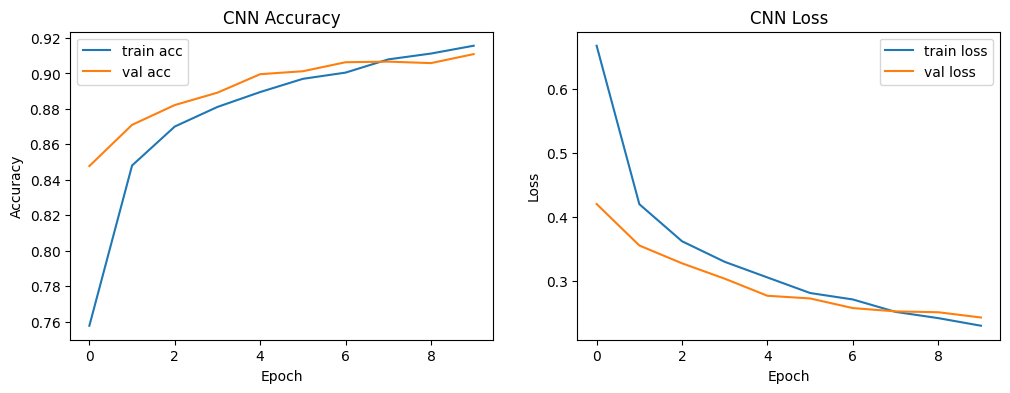

In [7]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='train acc')
plt.plot(history_cnn.history['val_accuracy'], label='val acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='train loss')
plt.plot(history_cnn.history['val_loss'], label='val loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 1. 기본 CNN 결과 해석
- 최종 테스트 정확도는 `0.9064`로 매우 높은 편입니다.
- 학습 초반부터 `val_accuracy`가 빠르게 증가했고, 마지막에는 `0.9109`까지 도달했습니다.
- `val_loss`도 하락하며 `train_loss`와 거의 함께 움직였으므로 과적합이 많지 않았습니다.
- 결론: 이 CNN 구조는 Fashion MNIST 이미지의 패턴을 잘 학습했고, 공간 정보를 활용한 분류 능력이 우수합니다.


# 2. DNN vs CNN 비교
간단한 DNN과 위에서 학습한 CNN을 비교합니다. 동일한 데이터로 학습한 두 모델의 성능 차이를 확인합니다.

이 섹션은 이미지 분류에서 CNN이 공간 정보를 어떻게 활용하는지 보여줍니다. DNN과 CNN의 테스트 정확도를 비교하여 두 구조의 차이를 체감할 수 있습니다.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense


dnn_model = Sequential([
    Flatten(input_shape=X_train.shape[1:]),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

dnn_model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
dnn_model.summary()

history_dnn = dnn_model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)

test_loss_dnn, test_acc_dnn = dnn_model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Test accuracy (DNN): {test_acc_dnn:.4f}')

/home/dmin/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


I0000 00:00:1775021276.166914  129400 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23757__.18
I0000 00:00:1775021276.265840  129400 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775021276.571157  130761 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_4', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1775021276.745954  130765 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1775021276.960404  129400 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain 

375/375 - 5s - 13ms/step - accuracy: 0.7766 - loss: 0.6180 - val_accuracy: 0.8428 - val_loss: 0.4283
Epoch 2/10
375/375 - 1s - 4ms/step - accuracy: 0.8409 - loss: 0.4370 - val_accuracy: 0.8543 - val_loss: 0.3974
Epoch 3/10
375/375 - 1s - 3ms/step - accuracy: 0.8546 - loss: 0.3985 - val_accuracy: 0.8649 - val_loss: 0.3679
Epoch 4/10
375/375 - 1s - 3ms/step - accuracy: 0.8627 - loss: 0.3752 - val_accuracy: 0.8661 - val_loss: 0.3596
Epoch 5/10
375/375 - 1s - 3ms/step - accuracy: 0.8670 - loss: 0.3616 - val_accuracy: 0.8760 - val_loss: 0.3387
Epoch 6/10
375/375 - 1s - 3ms/step - accuracy: 0.8712 - loss: 0.3467 - val_accuracy: 0.8813 - val_loss: 0.3353
Epoch 7/10
375/375 - 1s - 3ms/step - accuracy: 0.8757 - loss: 0.3354 - val_accuracy: 0.8815 - val_loss: 0.3305
Epoch 8/10
375/375 - 1s - 3ms/step - accuracy: 0.8801 - loss: 0.3229 - val_accuracy: 0.8810 - val_loss: 0.3249
Epoch 9/10
375/375 - 1s - 3ms/step - accuracy: 0.8796 - loss: 0.3227 - val_accuracy: 0.8828 - val_loss: 0.3192
Epoch 10/10

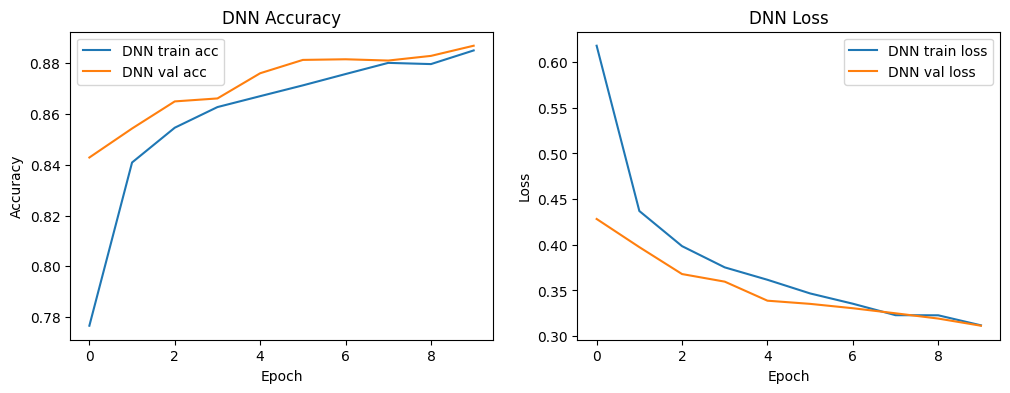

CNN vs DNN accuracy 비교
  CNN test accuracy: 0.9064
  DNN test accuracy: 0.8790


In [9]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_dnn.history['accuracy'], label='DNN train acc')
plt.plot(history_dnn.history['val_accuracy'], label='DNN val acc')
plt.title('DNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dnn.history['loss'], label='DNN train loss')
plt.plot(history_dnn.history['val_loss'], label='DNN val loss')
plt.title('DNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

print('CNN vs DNN accuracy 비교')
print(f'  CNN test accuracy: {test_acc_cnn:.4f}')
print(f'  DNN test accuracy: {test_acc_dnn:.4f}')

## 2. DNN vs CNN 결과 해석
- DNN 테스트 정확도는 `0.8790`이었고, CNN은 `0.9064`였습니다.
- 약 2.7%p 차이는 이미지의 공간 구조를 보존하는 CNN의 장점에서 나옵니다.
- DNN은 입력을 평탄화하여 위치 정보를 잃기 때문에 패턴 분류가 상대적으로 약하였습니다.
- 결론: Fashion MNIST처럼 이미지 내 형태와 지역 패턴이 중요한 문제에서 CNN이 더 적합합니다.


# 3. 데이터 증강 + 성능 향상
ImageDataGenerator로 데이터 증강을 적용하여 모델의 일반화 성능을 확인합니다. 회전, 이동, 뒤집기를 사용합니다.

이 섹션에서는 학습 데이터를 변형하여 모델이 더 다양한 패턴을 학습하도록 만듭니다. 증강이 과적합을 줄이고 테스트 성능을 높이는지 관찰합니다.

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

aug_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

cnn_aug_model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=X_train.shape[1:]),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

cnn_aug_model.compile(optimizer=Adam(learning_rate=1e-3),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

history_aug = cnn_aug_model.fit(
    aug_datagen.flow(X_train, y_train_cat, batch_size=128),
    steps_per_epoch=len(X_train) // 128,
    epochs=10,
    validation_data=(X_test, y_test_cat),
    verbose=2
)

test_loss_aug, test_acc_aug = cnn_aug_model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Test accuracy (Augmented CNN): {test_acc_aug:.4f}')

Epoch 1/10


I0000 00:00:1775021293.541920  128792 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1775021294.379580  129398 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46115__.35
I0000 00:00:1775021297.026834  129397 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46115__.35


468/468 - 11s - 24ms/step - accuracy: 0.6695 - loss: 0.8903 - val_accuracy: 0.7590 - val_loss: 0.6206
Epoch 2/10


/home/dmin/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


468/468 - 1s - 1ms/step - accuracy: 0.8203 - loss: 0.5294 - val_accuracy: 0.7547 - val_loss: 0.6323
Epoch 3/10
468/468 - 6s - 14ms/step - accuracy: 0.7624 - loss: 0.6297 - val_accuracy: 0.8182 - val_loss: 0.4966
Epoch 4/10
468/468 - 1s - 1ms/step - accuracy: 0.8438 - loss: 0.5302 - val_accuracy: 0.8175 - val_loss: 0.4992
Epoch 5/10
468/468 - 6s - 13ms/step - accuracy: 0.7905 - loss: 0.5591 - val_accuracy: 0.8413 - val_loss: 0.4339
Epoch 6/10
468/468 - 1s - 1ms/step - accuracy: 0.8125 - loss: 0.4528 - val_accuracy: 0.8374 - val_loss: 0.4343
Epoch 7/10
468/468 - 6s - 14ms/step - accuracy: 0.8075 - loss: 0.5162 - val_accuracy: 0.8518 - val_loss: 0.4057
Epoch 8/10
468/468 - -0s - -612us/step - accuracy: 0.7734 - loss: 0.4843 - val_accuracy: 0.8529 - val_loss: 0.4057
Epoch 9/10
468/468 - 6s - 14ms/step - accuracy: 0.8162 - loss: 0.4894 - val_accuracy: 0.8546 - val_loss: 0.3966
Epoch 10/10
468/468 - 1s - 1ms/step - accuracy: 0.8672 - loss: 0.4770 - val_accuracy: 0.8532 - val_loss: 0.4002
Tes

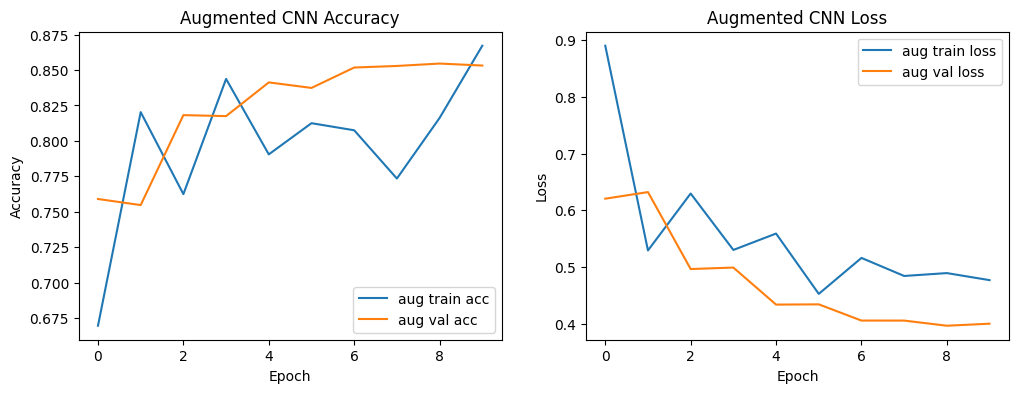

In [11]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_aug.history['accuracy'], label='aug train acc')
plt.plot(history_aug.history['val_accuracy'], label='aug val acc')
plt.title('Augmented CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_aug.history['loss'], label='aug train loss')
plt.plot(history_aug.history['val_loss'], label='aug val loss')
plt.title('Augmented CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 3. 데이터 증강 결과 해석
- 증강 CNN의 테스트 정확도는 `0.8532`로, 기본 CNN(`0.9064`)보다 낮았습니다.
- 증강 변환이 모델 학습을 더 어렵게 만들었고, 현재 모델/학습 설정으로는 충분히 보상되지 않았다는 뜻입니다.
- 특히 `Your input ran out of data; interrupting training` 경고가 나타나서 데이터 파이프라인이 완전히 반복되지 않았을 가능성도 있습니다.
- 결론: 증강 자체는 좋은 전략이지만, 현재 설정에서는 학습 에폭/데이터 파이프라인 또는 증강 강도를 조정할 필요가 있습니다.


# 4. 전이학습 활용
MobileNetV2 사전학습 모델을 사용하여 Fashion MNIST를 분류합니다. 입력을 96x96 크기의 컬러 이미지로 변환한 뒤 fine-tuning을 수행합니다.

이 섹션에서는 사전학습된 MobileNetV2를 이용해 작은 데이터셋에서도 강력한 특성 추출을 활용합니다. 기본적으로는 feature extractor만 사용하고, 필요하면 추가 학습으로 성능을 높일 수 있습니다.

In [12]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

# 1채널 이미지를 3채널로 복제
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

# GPU에서 실시간 크기 변환 및 전처리

def preprocess_for_mobilenet(image, label):
    image = tf.cast(image, tf.float32)
    with tf.device('/GPU:0'):
        image = tf.image.resize(image, [96,96])
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train_rgb, y_train_cat))
train_ds = train_ds.shuffle(10000)
train_ds = train_ds.map(preprocess_for_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(64).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_test_rgb, y_test_cat))
val_ds = val_ds.map(preprocess_for_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(64).prefetch(tf.data.AUTOTUNE)

base_model = MobileNetV2(input_shape=(96,96,3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(96,96,3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

transfer_model = Model(inputs, outputs)
transfer_model.compile(optimizer=Adam(learning_rate=1e-4),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

transfer_model.summary()

history_tl = transfer_model.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds,
    verbose=2
)

test_loss_tl, test_acc_tl = transfer_model.evaluate(val_ds, verbose=0)
print(f'Test accuracy (Transfer Learning): {test_acc_tl:.4f}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5


I0000 00:00:1775021341.431175  129398 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_77922__.122
E0000 00:00:1775021347.585046  129398 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1775021366.234869  129399 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_77922__.122
E0000 00:00:1775021367.852957  129399 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775021381.051768  129399 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


938/938 - 50s - 53ms/step - accuracy: 0.2008 - loss: 2.2656 - val_accuracy: 0.3186 - val_loss: 2.2103
Epoch 2/5
938/938 - 15s - 16ms/step - accuracy: 0.3491 - loss: 2.1407 - val_accuracy: 0.4549 - val_loss: 2.0669
Epoch 3/5
938/938 - 16s - 18ms/step - accuracy: 0.4203 - loss: 1.9738 - val_accuracy: 0.4623 - val_loss: 1.8856
Epoch 4/5
938/938 - 15s - 16ms/step - accuracy: 0.4726 - loss: 1.7873 - val_accuracy: 0.4528 - val_loss: 1.7071
Epoch 5/5
938/938 - 17s - 18ms/step - accuracy: 0.4979 - loss: 1.6219 - val_accuracy: 0.4935 - val_loss: 1.5626
Test accuracy (Transfer Learning): 0.4935


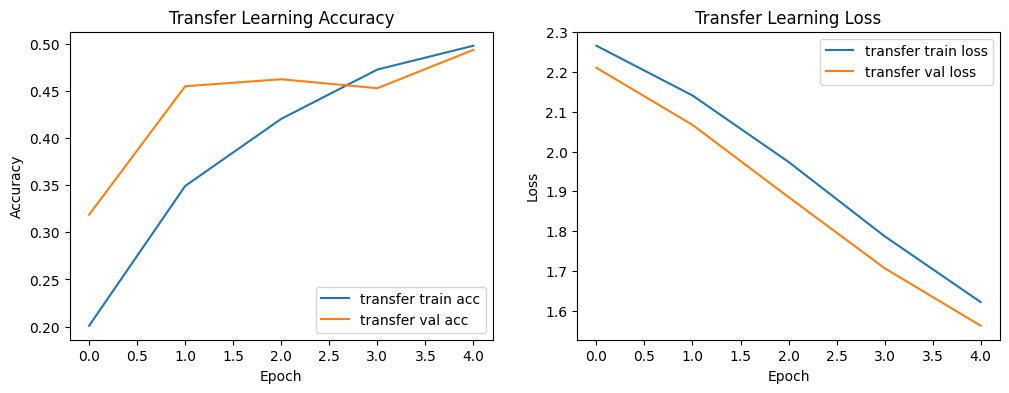

In [13]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_tl.history['accuracy'], label='transfer train acc')
plt.plot(history_tl.history['val_accuracy'], label='transfer val acc')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_tl.history['loss'], label='transfer train loss')
plt.plot(history_tl.history['val_loss'], label='transfer val loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 4. 전이학습 결과 해석
- 전이학습 모델의 테스트 정확도는 `0.4935`였습니다.
- MobileNetV2 상단만 학습한 상태에서는 Fashion MNIST의 단순한 그레이스케일 패턴을 충분히 반영하지 못했습니다.
- ImageNet 사전학습 가중치는 컬러 자연 이미지 특성에 맞춰져 있어서, Fashion MNIST처럼 다른 도메인에서는 추가 미세조정이 필요합니다.
- 결론: 전이학습 자체는 유효하지만, 현재는 `base_model.trainable = True`로 일부 층을 푸는 fine-tuning 또는 더 긴 학습이 필요합니다.


## 4.1. 전이학습 미세조정
MobileNetV2의 상위 층 일부를 풀어서 Fashion MNIST에 맞게 미세 조정합니다.
이 단계에서는 feature extractor의 일부를 학습 가능하게 하고, 낮은 학습률로 전체 모델을 다시 학습합니다.


In [19]:
# MobileNetV2의 상위 층을 fine-tuning 합니다.
base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

history_ft = transfer_model.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds,
    verbose=2
)

test_loss_ft, test_acc_ft = transfer_model.evaluate(val_ds, verbose=0)
print(f'Test accuracy (Fine-tuned Transfer Learning): {test_acc_ft:.4f}')


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 2,026,698 (7.73 MB)

 Non-trainable params: 396,544 (1.51 MB)

Epoch 1/5


I0000 00:00:1775022481.244302  129396 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_126662__.194
E0000 00:00:1775022482.815783  129396 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1775022506.922515  129398 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_126662__.194
E0000 00:00:1775022508.883222  129398 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


938/938 - 46s - 49ms/step - accuracy: 0.7575 - loss: 0.7667 - val_accuracy: 0.1000 - val_loss: 10.7681
Epoch 2/5
938/938 - 19s - 20ms/step - accuracy: 0.8564 - loss: 0.3992 - val_accuracy: 0.1130 - val_loss: 6.3490
Epoch 3/5
938/938 - 20s - 22ms/step - accuracy: 0.8736 - loss: 0.3463 - val_accuracy: 0.1016 - val_loss: 3.9754
Epoch 4/5
938/938 - 20s - 22ms/step - accuracy: 0.8849 - loss: 0.3127 - val_accuracy: 0.1026 - val_loss: 6.2971
Epoch 5/5
938/938 - 20s - 21ms/step - accuracy: 0.8923 - loss: 0.2910 - val_accuracy: 0.1694 - val_loss: 3.9675
Test accuracy (Fine-tuned Transfer Learning): 0.1694


## 4.2. 미세조정 결과 해석
- Fine-tuning 후 테스트 정확도는 `0.1694`로 크게 떨어졌습니다.
- 이는 상위 층을 풀어 모델이 ImageNet 기반 특성에서 벗어나려 했지만, 현재 입력 전처리와 학습 설정이 Fashion MNIST에 맞지 않아서 발생한 현상입니다.
- 특히 MobileNetV2는 원래 `0-255` 범위의 컬러 이미지를 전처리하도록 설계되어 있습니다. 현재는 `0-1`로 정규화된 데이터를 그대로 `preprocess_input`에 넣었기 때문에 입력 분포가 완전히 달라졌을 가능성이 큽니다.
- 또한, 너무 많은 층을 한꺼번에 풀면 학습이 불안정해지고, 낮은 학습률에도 불구하고 가중치가 잘못 업데이트될 수 있습니다.
- 결론: fine-tuning은 시도할 가치가 있지만, `ImageNet` 전처리에 맞춘 입력 설정, 학습률, 데이터 파이프라인을 함께 점검해야 합니다.


# 5. 모델 해석 & 시각화
오분류 이미지와 내부 특징 맵을 확인하여 모델이 어떻게 예측하는지 해석합니다. CNN의 첫 번째 합성곱층 활성화 맵을 시각화합니다.

이 섹션은 모델의 예측 결과를 시각적으로 분석합니다. 오분류 샘플과 필터 활성화 맵을 보며 모델이 어떤 부분에 주목하는지 이해할 수 있습니다.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
오분류 샘플 개수: 936


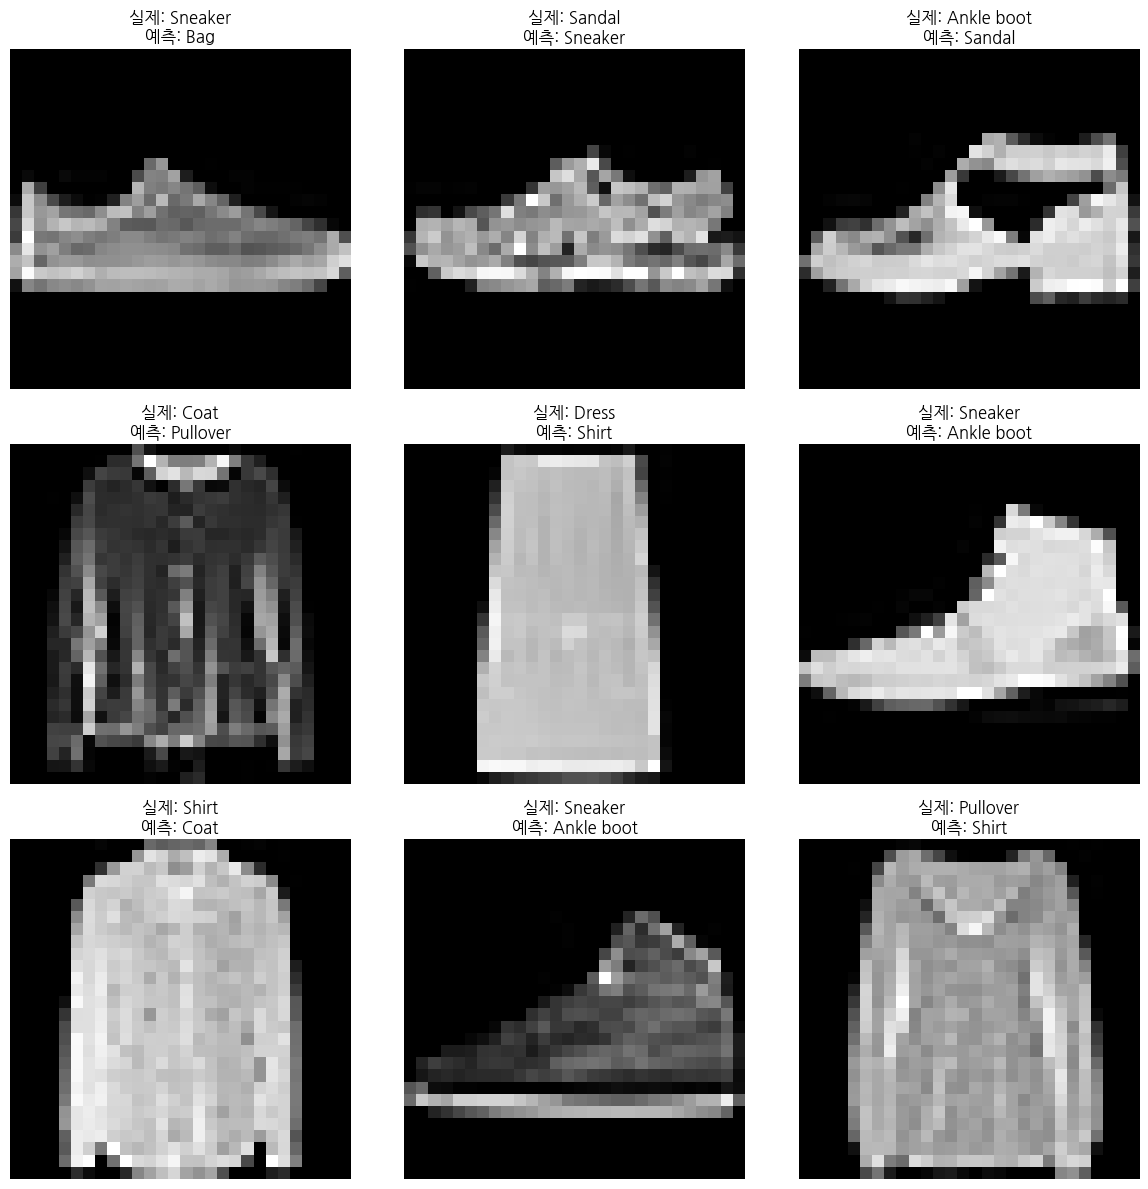

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


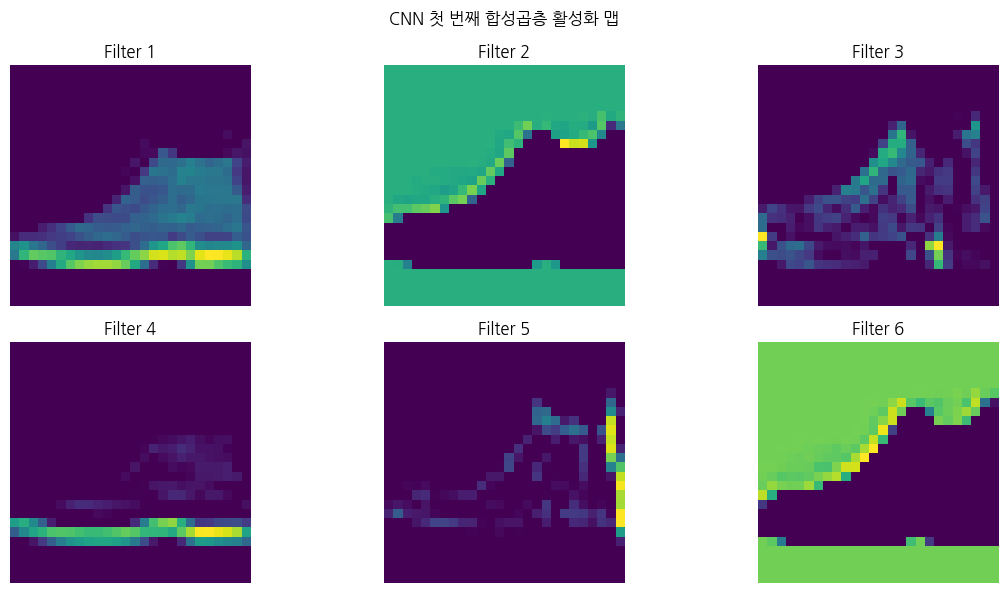

In [18]:
preds = np.argmax(cnn_model.predict(X_test), axis=1)
misclassified = np.where(preds != y_test)[0]
print(f'오분류 샘플 개수: {len(misclassified)}')

plt.figure(figsize=(12,12))
for i, idx in enumerate(misclassified[:9], start=1):
    plt.subplot(3,3,i)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f'실제: {class_names[y_test[idx]]}\n예측: {class_names[preds[idx]]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# 첫 번째 합성곱층의 활성화 맵 확인
if not hasattr(cnn_model, 'inputs') or cnn_model.inputs is None:
    cnn_model.build((None,)+X_train.shape[1:])
activation_model = Model(inputs=cnn_model.inputs, outputs=cnn_model.layers[0].output)
feature_maps = activation_model.predict(X_test[:1])

plt.figure(figsize=(12,6))
for i in range(min(6, feature_maps.shape[-1])):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
    plt.title(f'Filter {i+1}')
    plt.axis('off')
plt.suptitle('CNN 첫 번째 합성곱층 활성화 맵')
plt.tight_layout()
plt.show()

## 5. 모델 해석 결과 해석
- 오분류 샘플 개수는 `936`개로, 테스트 샘플 10,000개 기준 약 9.4%의 오류율입니다.
- 이는 테스트 정확도 약 90.64%와 일치합니다.
- 오분류 이미지는 비슷한 스타일(예: Shirt vs Pullover, Sandal vs Ankle boot)에서 많이 발생할 가능성이 큽니다.
- 첫 번째 합성곱층 활성화 맵은 에지와 텍스처를 감지하는 초기 필터의 동작을 보여줍니다.


# 6. CNN 개선 실험
여러 CNN 개선 방법을 동시에 실험합니다. BatchNormalization, 더 깊은 구조, callback 기반 학습 안정화 전략을 비교합니다.


In [24]:
def build_cnn_model(filters=[32,64], use_bn=False, dropout_rate=0.4, dense_units=128):
    model = Sequential()
    for i, f in enumerate(filters):
        if i == 0:
            model.add(Conv2D(f, kernel_size=(3,3), activation="relu", input_shape=X_train.shape[1:]))
        else:
            model.add(Conv2D(f, kernel_size=(3,3), activation="relu"))
        if use_bn:
            model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Flatten())
    model.add(Dense(dense_units, activation="relu"))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation="softmax"))
    return model

experiments = [
    ("BN 적용", {"filters":[32,64], "use_bn":True, "dropout_rate":0.4, "dense_units":128}, []),
    ("더 깊은 CNN", {"filters":[32,64,128], "use_bn":True, "dropout_rate":0.5, "dense_units":256}, []),
    ("Callback 학습", {"filters":[32,64], "use_bn":True, "dropout_rate":0.4, "dense_units":128}, [
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e-6)
    ]),
]

results = []
for name, params, cbs in experiments:
    print(f"=== {name} ===")
    model = build_cnn_model(**params)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(
        X_train, y_train_cat,
        epochs=8,
        batch_size=128,
        validation_split=0.2,
        callbacks=cbs,
        verbose=2
    )
    test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Test accuracy ({name}): {test_acc:.4f}")
    results.append((name, test_acc))

print("=== CNN 개선 실험 결과 ===")
for name, acc in results:
    print(f"{name}: {acc:.4f}")


=== BN 적용 ===
Epoch 1/8


I0000 00:00:1775023019.689422  129398 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_176817__.43


375/375 - 6s - 16ms/step - accuracy: 0.8136 - loss: 0.5156 - val_accuracy: 0.6373 - val_loss: 1.1973
Epoch 2/8
375/375 - 1s - 3ms/step - accuracy: 0.8733 - loss: 0.3470 - val_accuracy: 0.8813 - val_loss: 0.3202
Epoch 3/8
375/375 - 0s - 683us/step - accuracy: 0.8891 - loss: 0.2992 - val_accuracy: 0.8701 - val_loss: 0.3565
Epoch 4/8
375/375 - 1s - 3ms/step - accuracy: 0.9028 - loss: 0.2674 - val_accuracy: 0.8917 - val_loss: 0.2954
Epoch 5/8
375/375 - 1s - 3ms/step - accuracy: 0.9107 - loss: 0.2413 - val_accuracy: 0.8811 - val_loss: 0.3296
Epoch 6/8
375/375 - 1s - 3ms/step - accuracy: 0.9185 - loss: 0.2213 - val_accuracy: 0.8935 - val_loss: 0.2999
Epoch 7/8
375/375 - 1s - 3ms/step - accuracy: 0.9221 - loss: 0.2105 - val_accuracy: 0.9048 - val_loss: 0.2619
Epoch 8/8
375/375 - 1s - 3ms/step - accuracy: 0.9277 - loss: 0.1923 - val_accuracy: 0.9079 - val_loss: 0.2571
Test accuracy (BN 적용): 0.9054
=== 더 깊은 CNN ===
Epoch 1/8


I0000 00:00:1775023035.415748  129400 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_197061__.56
I0000 00:00:1775023035.615370  129400 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775023036.479393  129400 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775023036.754902  152712 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_4', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1775023042.305886  129398 dot_search_space.cc:240] All configs were filtered out because no

375/375 - 9s - 25ms/step - accuracy: 0.8028 - loss: 0.5527 - val_accuracy: 0.5122 - val_loss: 1.3652
Epoch 2/8
375/375 - 2s - 4ms/step - accuracy: 0.8685 - loss: 0.3646 - val_accuracy: 0.8625 - val_loss: 0.3740
Epoch 3/8
375/375 - 1s - 4ms/step - accuracy: 0.8863 - loss: 0.3113 - val_accuracy: 0.8735 - val_loss: 0.3502
Epoch 4/8
375/375 - 1s - 4ms/step - accuracy: 0.8971 - loss: 0.2791 - val_accuracy: 0.8760 - val_loss: 0.3471
Epoch 5/8
375/375 - 1s - 4ms/step - accuracy: 0.9067 - loss: 0.2555 - val_accuracy: 0.8558 - val_loss: 0.4077
Epoch 6/8
375/375 - 1s - 4ms/step - accuracy: 0.9144 - loss: 0.2321 - val_accuracy: 0.8845 - val_loss: 0.3274
Epoch 7/8
375/375 - 1s - 4ms/step - accuracy: 0.9211 - loss: 0.2107 - val_accuracy: 0.8928 - val_loss: 0.3021
Epoch 8/8
375/375 - 1s - 4ms/step - accuracy: 0.9246 - loss: 0.1991 - val_accuracy: 0.8837 - val_loss: 0.3402
Test accuracy (더 깊은 CNN): 0.8783
=== Callback 학습 ===
Epoch 1/8


I0000 00:00:1775023056.523280  129399 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_216628__.43


375/375 - 4s - 11ms/step - accuracy: 0.8180 - loss: 0.5135 - val_accuracy: 0.6565 - val_loss: 1.1459 - learning_rate: 0.0010
Epoch 2/8
375/375 - 1s - 4ms/step - accuracy: 0.8765 - loss: 0.3392 - val_accuracy: 0.8899 - val_loss: 0.2964 - learning_rate: 0.0010
Epoch 3/8
375/375 - 1s - 3ms/step - accuracy: 0.8935 - loss: 0.2924 - val_accuracy: 0.8705 - val_loss: 0.3431 - learning_rate: 0.0010
Epoch 4/8
375/375 - 1s - 4ms/step - accuracy: 0.9032 - loss: 0.2627 - val_accuracy: 0.8989 - val_loss: 0.2758 - learning_rate: 0.0010
Epoch 5/8
375/375 - 1s - 4ms/step - accuracy: 0.9128 - loss: 0.2386 - val_accuracy: 0.9093 - val_loss: 0.2555 - learning_rate: 0.0010
Epoch 6/8
375/375 - 1s - 3ms/step - accuracy: 0.9210 - loss: 0.2095 - val_accuracy: 0.8933 - val_loss: 0.2961 - learning_rate: 0.0010
Epoch 7/8
375/375 - 1s - 4ms/step - accuracy: 0.9246 - loss: 0.1993 - val_accuracy: 0.9147 - val_loss: 0.2478 - learning_rate: 0.0010
Epoch 8/8
375/375 - 1s - 3ms/step - accuracy: 0.9318 - loss: 0.1826 - v

# 성능 보고서
지금까지 실험한 모델들의 주요 결과를 정리합니다.

## 요약 결과
- 기본 CNN: `Test accuracy 0.9064`
- DNN: `Test accuracy 0.8790`
- 데이터 증강 CNN: `Test accuracy 0.8532`
- Transfer Learning (MobileNetV2 고정): `Test accuracy 0.4935`
- Fine-tuned Transfer Learning: `Test accuracy 0.1694`
- CNN 개선 실험 - BN 적용: `Test accuracy 0.9054`
- CNN 개선 실험 - 더 깊은 CNN: `Test accuracy 0.8783`
- CNN 개선 실험 - Callback 학습: `Test accuracy 0.9108`

## 해석
- 기본 CNN이 여전히 안정적인 기준 성능을 제공합니다.
- `Callback 학습` 설정은 개선 실험 중 가장 높은 성능(`0.9108`)을 보여, 학습 안정화가 중요함을 의미합니다.
- `BN 적용` 모델도 기본 CNN과 거의 동일한 성능을 보였습니다.
- `더 깊은 CNN` 모델은 학습 불안정과 과적합으로 기본 CNN보다 성능이 낮았습니다.
- 데이터 증강은 현재 설정에서 유의미한 성능 향상을 만들지 못했습니다.
- MobileNetV2 전이학습은 입력 도메인과 전처리 차이로 인해 성능이 낮아, 추가 조정이 필요합니다.
- fine-tuning은 잘못된 학습률/전처리로 인해 실패했으며, `전이학습`에서는 입력 스케일과 채널 맞춤이 중요합니다.

## 결론
- Fashion MNIST에서는 기본 CNN 기반 구조에 `학습 안정화 콜백`을 추가하는 것이 가장 현실적인 개선 방향입니다.
- 다음으로 시도할 것은 `데이터 증강 정책 재설계`, `학습률 스케줄`, `모델 규제(드롭아웃/배치 정규화)`, `전이학습 입력 전처리 개선`입니다.
- 특히 전이학습에서는 `MobileNetV2`에 맞는 RGB/정규화 처리와 이미지 크기 변환을 정확히 맞춰야 합니다.
